# 🛒 The Retail Oracle — Instacart Reorder Prediction
**Covers:** Step 1 (Data Loading) → Step 6 (Feature Engineering)

---

## Step 1: Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✅ Imports done")

✅ Imports done


## Step 2: Data Loading

**Dataset:** Instacart Market Basket Analysis

| Table | Description |
|---|---|
| `aisles.csv` | 134 aisles |
| `departments.csv` | 21 departments |
| `products.csv` | 49,688 products |
| `orders.csv` | 3,421,083 orders from 206,209 users |
| `order_products__train.csv` | 1,384,617 rows (train labels) |

**`eval_set` in orders:**
- `'prior'`  → all historical orders (3,214,874 rows)
- `'train'`  → last order for training users (131,209 rows)
- `'test'`   → last order for test users (75,000 rows)

In [ ]:
DATA_PATH = r"C:\Users\shubh\OneDrive\Desktop\Project_ML\data\raw\\"

aisles               = pd.read_csv(DATA_PATH + "aisles.csv")
departments          = pd.read_csv(DATA_PATH + "departments.csv")
products             = pd.read_csv(DATA_PATH + "products.csv")
orders               = pd.read_csv(DATA_PATH + "orders.csv")
order_products_train = pd.read_csv(DATA_PATH + "order_products__train.csv")
order_products_prior = pd.read_csv(DATA_PATH + "order_products__prior.csv")

print(f"aisles:               {aisles.shape}")
print(f"departments:          {departments.shape}")
print(f"products:             {products.shape}")
print(f"orders:               {orders.shape}")
print(f"order_products_train: {order_products_train.shape}")
print(f"order_products_prior: {order_products_prior.shape}")

aisles:               (134, 2)
departments:          (21, 2)
products:             (49688, 4)
orders:               (3421083, 7)
order_products_train: (1384617, 4)
order_products_prior: (32434489, 4)


## Step 3: Data Understanding & Schema

### Schema Overview

**`orders.csv`**
- `order_id` → unique order identifier
- `user_id` → customer id
- `eval_set` → prior / train / test
- `order_number` → sequence number (1 = first order)
- `order_dow` → day of week (0=Sunday, 6=Saturday)
- `order_hour_of_day` → hour (0–23)
- `days_since_prior_order` → NULL for first order

**`order_products__train.csv` / `order_products__prior.csv`**
- `order_id` → links to orders.csv
- `product_id` → links to products.csv
- `add_to_cart_order` → 1st, 2nd… item added to cart
- `reordered` → **TARGET**: 1 = bought before, 0 = new

**`products.csv`** → product_id, product_name, aisle_id, department_id  
**`aisles.csv`** → aisle_id, aisle  
**`departments.csv`** → department_id, department

In [3]:
# Separate splits
prior_orders = orders[orders['eval_set'] == 'prior']
train_orders = orders[orders['eval_set'] == 'train']
test_orders  = orders[orders['eval_set'] == 'test']

print(f"Prior orders:  {prior_orders.shape[0]:,}")
print(f"Train orders:  {train_orders.shape[0]:,}")
print(f"Test orders:   {test_orders.shape[0]:,}")
print(f"Unique users:  {orders['user_id'].nunique():,}")

Prior orders:  3,214,874
Train orders:  131,209
Test orders:   75,000
Unique users:  206,209


## Step 4: Missing Value Analysis

In [4]:
print("=== Missing Value Report ===")
for name, df in [("orders", orders), ("order_products_train", order_products_train),
                 ("products", products)]:
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing):
        print(f"\n{name}:")
        for col, count in missing.items():
            print(f"  {col}: {count:,} ({count/len(df)*100:.2f}%)")
    else:
        print(f"\n{name}: No missing values ✅")

=== Missing Value Report ===

orders:
  days_since_prior_order: 206,209 (6.03%)

order_products_train: No missing values ✅

products: No missing values ✅


> **Key Finding:** `days_since_prior_order` has 206,209 NULLs → These are first-ever orders (`order_number == 1`) — expected, not a data quality issue.  
> **Strategy:** Fill with `0` and create a flag: `is_first_order = 1`

In [5]:
# Verify: all NULLs are order_number == 1
null_days = orders[orders['days_since_prior_order'].isnull()]
assert (null_days['order_number'] == 1).all(), "NULLs not all first orders!"
print("✅ Confirmed: All NULLs in days_since_prior_order are first orders (order_number=1)")

# Fix: fill with 0 and add flag
orders['days_since_prior_order'] = orders['days_since_prior_order'].fillna(0)
orders['is_first_order'] = (orders['order_number'] == 1).astype(int)

✅ Confirmed: All NULLs in days_since_prior_order are first orders (order_number=1)


## Step 5: Exploratory Data Analysis (EDA)

### 5A. Target Variable Analysis

Target (reordered) distribution:
  Reordered (1): 828,824  (59.9%)
  New (0):       555,793  (40.1%)

⚠️  Mild class imbalance: 0.60 vs 0.40
→ Use F1, Precision-Recall, ROC-AUC as evaluation metrics, not just Accuracy


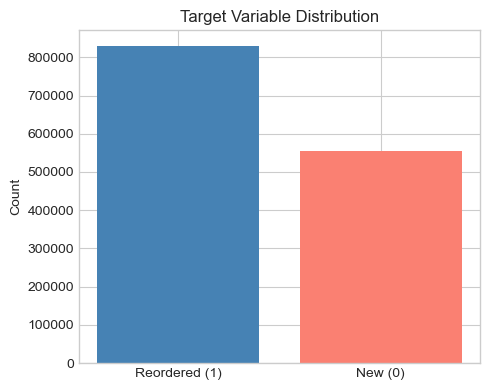

In [6]:
reorder_rate = order_products_train['reordered'].mean()
print(f"Target (reordered) distribution:")
print(f"  Reordered (1): {order_products_train['reordered'].sum():,}  ({reorder_rate*100:.1f}%)")
print(f"  New (0):       {(order_products_train['reordered']==0).sum():,}  ({(1-reorder_rate)*100:.1f}%)")
print(f"\n⚠️  Mild class imbalance: {reorder_rate:.2f} vs {1-reorder_rate:.2f}")
print("→ Use F1, Precision-Recall, ROC-AUC as evaluation metrics, not just Accuracy")

# Plot target distribution
fig, ax = plt.subplots(figsize=(5, 4))
labels = ['Reordered (1)', 'New (0)']
sizes  = [order_products_train['reordered'].sum(),
          (order_products_train['reordered'] == 0).sum()]
ax.bar(labels, sizes, color=['steelblue', 'salmon'])
ax.set_title('Target Variable Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

### 5B. Order Behavior Analysis

In [7]:
# Orders per user
orders_per_user = prior_orders.groupby('user_id')['order_id'].count()
print(f"Orders per user:")
print(f"  Min: {orders_per_user.min()}, Median: {orders_per_user.median()}, Max: {orders_per_user.max()}")
print(f"  >10 orders: {(orders_per_user > 10).mean()*100:.1f}% of users")

# Day-of-week patterns
dow_map = {0:'Sun',1:'Mon',2:'Tue',3:'Wed',4:'Thu',5:'Fri',6:'Sat'}
dow_counts = orders['order_dow'].map(dow_map).value_counts().reindex(
    ['Sun','Mon','Tue','Wed','Thu','Fri','Sat'])
print(f"\nTop order day: {dow_counts.idxmax()} ({dow_counts.max():,} orders)")
print(f"Peak hour: {orders['order_hour_of_day'].value_counts().idxmax()}:00")

# Days between orders
dspo = prior_orders['days_since_prior_order'].replace(0, np.nan).dropna()
print(f"\nDays between orders:")
print(f"  Mean: {dspo.mean():.1f},  Median: {dspo.median():.0f}")
print(f"  Weekly shoppers (7d ±1): {((dspo>=6)&(dspo<=8)).mean()*100:.1f}%")
print(f"  Monthly shoppers (28-30d): {((dspo>=28)&(dspo<=30)).mean()*100:.1f}%")

Orders per user:
  Min: 3, Median: 9.0, Max: 99
  >10 orders: 45.5% of users

Top order day: Sun (600,905 orders)
Peak hour: 10:00

Days between orders:
  Mean: 10.9,  Median: 7
  Weekly shoppers (7d ±1): 24.1%
  Monthly shoppers (28-30d): 11.8%


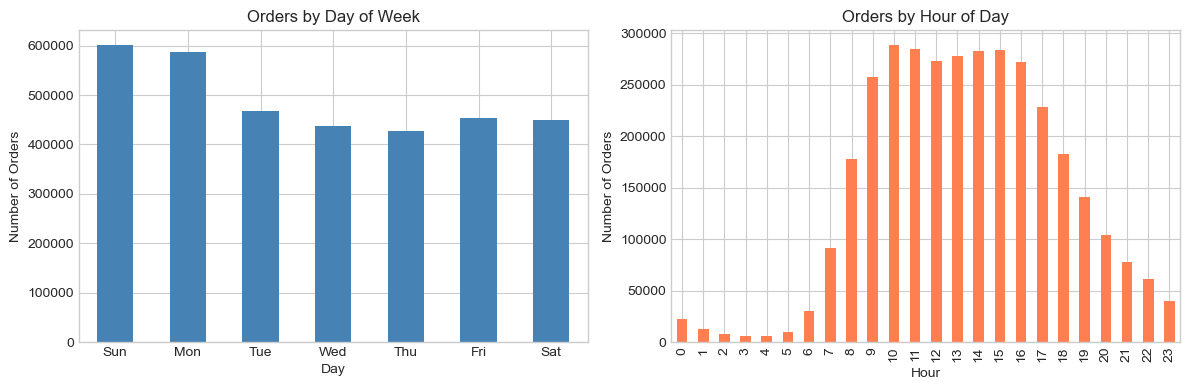

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Day of week
dow_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Orders by Day of Week')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Number of Orders')
axes[0].tick_params(axis='x', rotation=0)

# Hour of day
orders['order_hour_of_day'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Orders by Hour of Day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Number of Orders')

plt.tight_layout()
plt.show()

### 5C. Product & Basket Analysis

In [9]:
# Products per order in train
products_per_order = order_products_train.groupby('order_id')['product_id'].count()
print(f"Products per order:")
print(f"  Median: {products_per_order.median():.0f}, Mean: {products_per_order.mean():.1f}")
print(f"  Max: {products_per_order.max()}")

# Cart position analysis
cp_reorder = order_products_train.groupby('add_to_cart_order')['reordered'].mean()
print(f"\nReorder rate by cart position:")
print(f"  Position 1:  {cp_reorder.get(1, 0):.3f}")
print(f"  Position 5:  {cp_reorder.get(5, 0):.3f}")
print(f"  Position 10: {cp_reorder.get(10, 0):.3f}")
print("→ Items added early in cart are more likely to be reorders")

Products per order:
  Median: 9, Mean: 10.6
  Max: 80

Reorder rate by cart position:
  Position 1:  0.723
  Position 5:  0.623
  Position 10: 0.561
→ Items added early in cart are more likely to be reorders


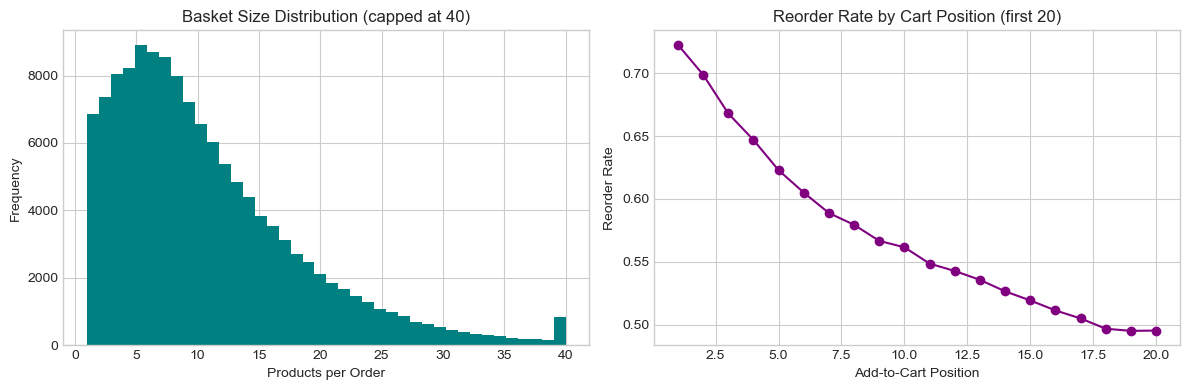

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Basket size distribution
products_per_order.clip(upper=40).plot(kind='hist', bins=40, ax=axes[0], color='teal')
axes[0].set_title('Basket Size Distribution (capped at 40)')
axes[0].set_xlabel('Products per Order')

# Reorder rate by cart position
cp_reorder.head(20).plot(ax=axes[1], marker='o', color='purple')
axes[1].set_title('Reorder Rate by Cart Position (first 20)')
axes[1].set_xlabel('Add-to-Cart Position')
axes[1].set_ylabel('Reorder Rate')

plt.tight_layout()
plt.show()

### 5D. Department & Aisle Analysis

In [11]:
prod_dept = products.merge(departments, on='department_id')
op_dept   = order_products_train.merge(prod_dept[['product_id','department']], on='product_id')

dept_volume = op_dept['department'].value_counts()
print(f"Top 5 departments by order volume:")
print(dept_volume.head(5).to_string())

dept_reorder = op_dept.groupby('department')['reordered'].mean().sort_values(ascending=False)
print(f"\nTop 5 departments by reorder rate:")
print(dept_reorder.head(5).round(3).to_string())

Top 5 departments by order volume:
department
produce       409087
dairy eggs    217051
snacks        118862
beverages     114046
frozen        100426

Top 5 departments by reorder rate:
department
dairy eggs    0.675
produce       0.665
beverages     0.658
bakery        0.634
pets          0.630


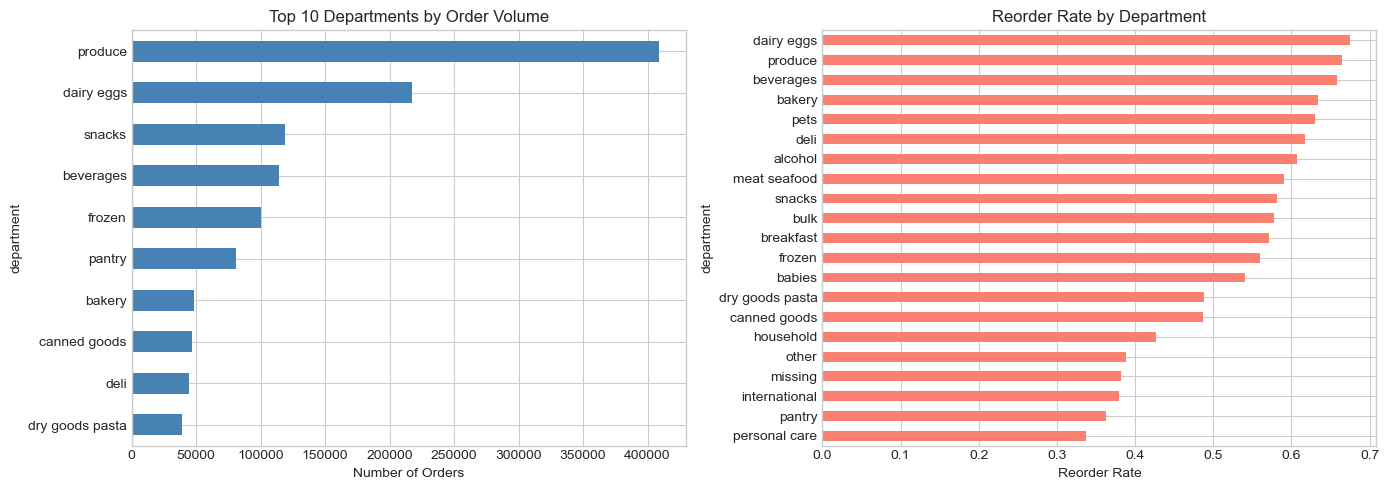

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dept_volume.head(10).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Departments by Order Volume')
axes[0].set_xlabel('Number of Orders')
axes[0].invert_yaxis()

dept_reorder.sort_values().plot(kind='barh', ax=axes[1], color='salmon')
axes[1].set_title('Reorder Rate by Department')
axes[1].set_xlabel('Reorder Rate')

plt.tight_layout()
plt.show()

## Step 6: Feature Engineering

**Feature Strategy: 3-Level Feature Groups**

| Group | Description |
|---|---|
| **A — User Features** | Who is this user? How do they shop? |
| **B — Product Features** | How popular is this product? How often is it reordered? |
| **C — User-Product Interaction** | How does THIS user relate to THIS product? |

**Target** for each `(user, product)` pair in the train set:  
`reordered = 1` if the product appears in their last order.

---

### 6A. User Features

In [13]:
print(">> Group A: User Features")

# Merge prior order_products with prior orders to get user context
prior_op = order_products_prior.merge(
    prior_orders[['order_id','user_id','order_number','order_dow',
                  'order_hour_of_day','days_since_prior_order']],
    on='order_id'
)

# Basic aggregation
user_feat = prior_orders.groupby('user_id').agg(
    user_total_orders        = ('order_id', 'count'),
    user_avg_days_between    = ('days_since_prior_order', 'mean'),
    user_std_days_between    = ('days_since_prior_order', 'std'),
    user_min_days_between    = ('days_since_prior_order', 'min'),
    user_max_days_between    = ('days_since_prior_order', 'max'),
    user_avg_order_hour      = ('order_hour_of_day', 'mean'),
    user_std_order_hour      = ('order_hour_of_day', 'std'),
).reset_index()

# Total products and unique products purchased
user_prod_stats = prior_op.groupby('user_id').agg(
    user_total_products      = ('product_id', 'count'),
    user_unique_products     = ('product_id', 'nunique'),
    user_total_reorders      = ('reordered', 'sum'),
).reset_index()

user_prod_stats['user_reorder_rate'] = (
    user_prod_stats['user_total_reorders'] /
    user_prod_stats['user_total_products']
)
user_prod_stats['user_avg_basket_size'] = (
    user_prod_stats['user_total_products'] /
    user_prod_stats['user_total_products'].clip(lower=1)
)

user_feat = user_feat.merge(user_prod_stats, on='user_id', how='left')

# Fill NaN in std (single-order users have no std)
user_feat['user_std_days_between'] = user_feat['user_std_days_between'].fillna(0)
user_feat['user_std_order_hour']   = user_feat['user_std_order_hour'].fillna(0)

print(f"  ✅ User features: {user_feat.shape[1]} columns, {user_feat.shape[0]:,} users")
print(f"  Columns: {list(user_feat.columns)}")
user_feat.head(3)

>> Group A: User Features
  ✅ User features: 13 columns, 206,209 users
  Columns: ['user_id', 'user_total_orders', 'user_avg_days_between', 'user_std_days_between', 'user_min_days_between', 'user_max_days_between', 'user_avg_order_hour', 'user_std_order_hour', 'user_total_products', 'user_unique_products', 'user_total_reorders', 'user_reorder_rate', 'user_avg_basket_size']


,user_id,user_total_orders,user_avg_days_between,user_std_days_between,user_min_days_between,user_max_days_between,user_avg_order_hour,user_std_order_hour,user_total_products,user_unique_products,user_total_reorders,user_reorder_rate,user_avg_basket_size
0,1,10,19.555556,9.395625,0.0,30.0,10.300000,3.591657,59,18,41,0.694915,1.0
1,2,14,15.230769,9.867065,3.0,30.0,10.571429,1.554858,195,102,93,0.476923,1.0
2,3,12,12.090909,5.375026,7.0,21.0,16.416667,1.443376,88,33,55,0.625000,1.0


### 6B. Product Features

In [14]:
print(">> Group B: Product Features")

prod_feat = prior_op.groupby('product_id').agg(
    product_total_orders     = ('order_id', 'count'),
    product_reorder_rate     = ('reordered', 'mean'),
    product_avg_cart_pos     = ('add_to_cart_order', 'mean'),
    product_std_cart_pos     = ('add_to_cart_order', 'std'),
    product_unique_users     = ('user_id', 'nunique'),
).reset_index()

prod_feat['product_std_cart_pos'] = prod_feat['product_std_cart_pos'].fillna(0)

# Attach metadata
prod_feat = prod_feat.merge(
    products.merge(departments, on='department_id').merge(aisles, on='aisle_id'),
    on='product_id', how='left'
)

# Department and aisle level reorder rates (smoothed signal)
dept_reorder_rates = (
    prod_feat.groupby('department')['product_reorder_rate']
    .mean().reset_index()
    .rename(columns={'product_reorder_rate': 'dept_avg_reorder_rate'})
)
aisle_reorder_rates = (
    prod_feat.groupby('aisle')['product_reorder_rate']
    .mean().reset_index()
    .rename(columns={'product_reorder_rate': 'aisle_avg_reorder_rate'})
)
prod_feat = prod_feat.merge(dept_reorder_rates, on='department', how='left')
prod_feat = prod_feat.merge(aisle_reorder_rates, on='aisle', how='left')

key_cols = ['product_id','product_total_orders','product_reorder_rate',
            'product_avg_cart_pos','product_unique_users',
            'dept_avg_reorder_rate','aisle_avg_reorder_rate']

print(f"  ✅ Product features: {prod_feat.shape[1]} columns, {prod_feat.shape[0]:,} products")
print(f"  Key columns: {key_cols}")
prod_feat[key_cols].head(3)

>> Group B: Product Features
  ✅ Product features: 13 columns, 49,677 products
  Key columns: ['product_id', 'product_total_orders', 'product_reorder_rate', 'product_avg_cart_pos', 'product_unique_users', 'dept_avg_reorder_rate', 'aisle_avg_reorder_rate']


,product_id,product_total_orders,product_reorder_rate,product_avg_cart_pos,product_unique_users,dept_avg_reorder_rate,aisle_avg_reorder_rate
0,1,1852,0.613391,5.801836,716,0.438319,0.414080
1,2,90,0.133333,9.888889,78,0.242846,0.116439
2,3,277,0.732852,6.415162,74,0.471714,0.370010


### 6C. User-Product Interaction Features

In [15]:
print(">> Group C: User-Product Interaction Features")

# For each (user, product) pair in prior orders
up_feat = prior_op.groupby(['user_id', 'product_id']).agg(
    up_times_ordered         = ('order_id', 'count'),
    up_reorder_count         = ('reordered', 'sum'),
    up_avg_cart_position     = ('add_to_cart_order', 'mean'),
    up_first_order_number    = ('order_number', 'min'),
    up_last_order_number     = ('order_number', 'max'),
).reset_index()

# Derived features
up_feat['up_reorder_rate'] = up_feat['up_reorder_count'] / up_feat['up_times_ordered']
up_feat['up_orders_span']  = up_feat['up_last_order_number'] - up_feat['up_first_order_number']
up_feat['up_buy_frequency'] = up_feat['up_times_ordered'] / (up_feat['up_orders_span'] + 1)

# Recency: how many orders ago was last purchase?
user_last_order = prior_orders.groupby('user_id')['order_number'].max().reset_index()
user_last_order.columns = ['user_id', 'user_max_order']
up_feat = up_feat.merge(user_last_order, on='user_id', how='left')
up_feat['up_orders_since_last'] = (
    up_feat['user_max_order'] - up_feat['up_last_order_number']
)

# Recency score: items not ordered recently are less likely to be reordered
up_feat['up_recency_score'] = 1 / (up_feat['up_orders_since_last'] + 1)

print(f"  ✅ User-Product features: {up_feat.shape[1]} columns, {up_feat.shape[0]:,} pairs")
print(f"  Columns: {list(up_feat.columns)}")
up_feat.head(3)

>> Group C: User-Product Interaction Features
  ✅ User-Product features: 13 columns, 13,307,953 pairs
  Columns: ['user_id', 'product_id', 'up_times_ordered', 'up_reorder_count', 'up_avg_cart_position', 'up_first_order_number', 'up_last_order_number', 'up_reorder_rate', 'up_orders_span', 'up_buy_frequency', 'user_max_order', 'up_orders_since_last', 'up_recency_score']


,user_id,product_id,up_times_ordered,up_reorder_count,up_avg_cart_position,up_first_order_number,up_last_order_number,up_reorder_rate,up_orders_span,up_buy_frequency,user_max_order,up_orders_since_last,up_recency_score
0,1,196,10,9,1.400000,1,10,0.900000,9,1.0,10,0,1.000000
1,1,10258,9,8,3.333333,2,10,0.888889,8,1.0,10,0,1.000000
2,1,10326,1,0,5.000000,5,5,0.000000,0,1.0,10,5,0.166667


### 6D. Assemble Final Feature Matrix

In [16]:
print(">> Assembling Final Feature Matrix...")

# Get all (user, product) pairs to predict for train set
train_users = train_orders[['order_id','user_id']].copy()

# Candidate products = all products user has ordered in prior
candidates = up_feat[['user_id','product_id']].copy()
candidates = candidates.merge(train_users, on='user_id', how='inner')

# Attach features
final_df = candidates.merge(up_feat.drop('user_max_order', axis=1),
                            on=['user_id','product_id'], how='left')
final_df = final_df.merge(user_feat, on='user_id', how='left')
final_df = final_df.merge(prod_feat[key_cols], on='product_id', how='left')

# Attach labels
labels = order_products_train[['order_id','product_id','reordered']].copy()
final_df = final_df.merge(labels, on=['order_id','product_id'], how='left')
final_df['reordered'] = final_df['reordered'].fillna(0).astype(int)

print(f"\n  ✅ Final feature matrix: {final_df.shape[1]} columns, {final_df.shape[0]:,} rows")
print(f"  Target distribution:")
print(f"    Positive (reordered=1): {final_df['reordered'].sum():,} ({final_df['reordered'].mean()*100:.1f}%)")
print(f"    Negative (reordered=0): {(final_df['reordered']==0).sum():,}")

final_df.head(3)

>> Assembling Final Feature Matrix...

  ✅ Final feature matrix: 32 columns, 8,474,661 rows
  Target distribution:
    Positive (reordered=1): 828,824 (9.8%)
    Negative (reordered=0): 7,645,837


,user_id,product_id,order_id,up_times_ordered,up_reorder_count,up_avg_cart_position,up_first_order_number,up_last_order_number,up_reorder_rate,up_orders_span,...,user_total_reorders,user_reorder_rate,user_avg_basket_size,product_total_orders,product_reorder_rate,product_avg_cart_pos,product_unique_users,dept_avg_reorder_rate,aisle_avg_reorder_rate,reordered
0,1,196,1187899,10,9,1.400000,1,10,0.900000,9,...,41,0.694915,1.0,35791,0.776480,3.721774,8000,0.471714,0.486456,1
1,1,10258,1187899,9,8,3.333333,2,10,0.888889,8,...,41,0.694915,1.0,1946,0.713772,4.277492,557,0.438319,0.394145,1
2,1,10326,1187899,1,0,5.000000,5,5,0.000000,0,...,41,0.694915,1.0,5526,0.652009,4.191097,1923,0.412660,0.416092,0


### 6E. Feature Importance Hypotheses

| Rank | Feature | Expected Predictive Power |
|---|---|---|
| 1 | `up_times_ordered` | More purchases = higher reorder chance | HIGH |
| 2 | `up_reorder_rate` | Direct measure of user-product loyalty | HIGH |
| 3 | `product_reorder_rate` | Global popularity of product being reordered | HIGH |
| 4 | `up_orders_since_last` | Recency — if bought recently, likely to reorder | HIGH |
| 5 | `up_buy_frequency` | How regularly the user buys this product | MEDIUM |
| 6 | `user_reorder_rate` | Habitual buyer tends to reorder more | MEDIUM |
| 7 | `product_avg_cart_pos` | Items added early = habit = reorder | MEDIUM |
| 8 | `up_avg_cart_position` | Same but user-specific | MEDIUM |
| 9 | `user_total_orders` | More experienced users have clearer preferences | LOW |
| 10 | `dept_avg_reorder_rate` | Some departments (personal care) are high-reorder | LOW |

### 6F. Save Processed Data

In [17]:
import os
os.makedirs('data/processed', exist_ok=True)

print(">> Saving processed files...")
user_feat.to_csv('data/processed/user_features.csv', index=False)
prod_feat.to_csv('data/processed/product_features.csv', index=False)
up_feat.to_csv('data/processed/user_product_features.csv', index=False)
final_df.to_csv('data/processed/final_features_train.csv', index=False)
print("✅ All files saved to data/processed/")

print("\n" + "="*60)
print("COMPLETED: Data Loading → EDA → Feature Engineering")
print("NEXT STEPS: Baseline Model → Model Comparison → Evaluation")
print("="*60)

>> Saving processed files...
✅ All files saved to data/processed/

COMPLETED: Data Loading → EDA → Feature Engineering
NEXT STEPS: Baseline Model → Model Comparison → Evaluation
